In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
# Load Data
try:
    df = pd.read_csv("data/compare_results.csv")
    print(f"Successfully loaded {len(df)} rows from results.csv")
    display(df.head())
except FileNotFoundError:
    print("Data file not found. Ensure you have run some games via the main.py CLI and saved to results.csv.")

Successfully loaded 4400 rows from results.csv


,player,embedding,algorithm,k_nn,n_long,start,target,success,pth_len,opt_len,diff,path_str
0,greedy,gemini,k_nn+n_random,5,0,waterproof,harrison,False,-1,16,-1,waterproof -> protective -> protected -> prote...
1,greedy,gemini,k_nn+n_random,5,0,compliant,heel,False,-1,12,-1,compliant -> comp -> sentence -> a -> an -> se...
2,greedy,gemini,k_nn+n_random,5,0,succeed,conducted,False,-1,14,-1,succeed -> successfully -> accomplished -> com...
3,greedy,gemini,k_nn+n_random,5,0,greg,objectives,False,-1,12,-1,greg -> gr -> sentence -> sentences -> a -> se...
4,greedy,gemini,k_nn+n_random,5,0,members,officials,False,-1,12,-1,members -> individuals -> peoples -> people ->...


In [13]:
# Isolate probabilistic data
if 'algorithm' in df.columns:
    df_prob = df[df['algorithm'] == 'inv_knn+n_probabilistic'].copy()
    
    # We generally compare performance across different values of k_nn (with n_long implicitly equal to 25 - k_nn)
    
    human_data = df_prob[df_prob['player'] == 'human']
    comp_data = df_prob[df_prob['player'] == 'greedy']
    
    print(f"Human Probability Games: {len(human_data)}")
    print(f"Computer Probability Games: {len(comp_data)}")

Human Probability Games: 0
Computer Probability Games: 2000


### Plot: Average Path Difference (Human vs Computer)
We plot the difference between the shortest possible path and the path taken by the player. Successful completions only.

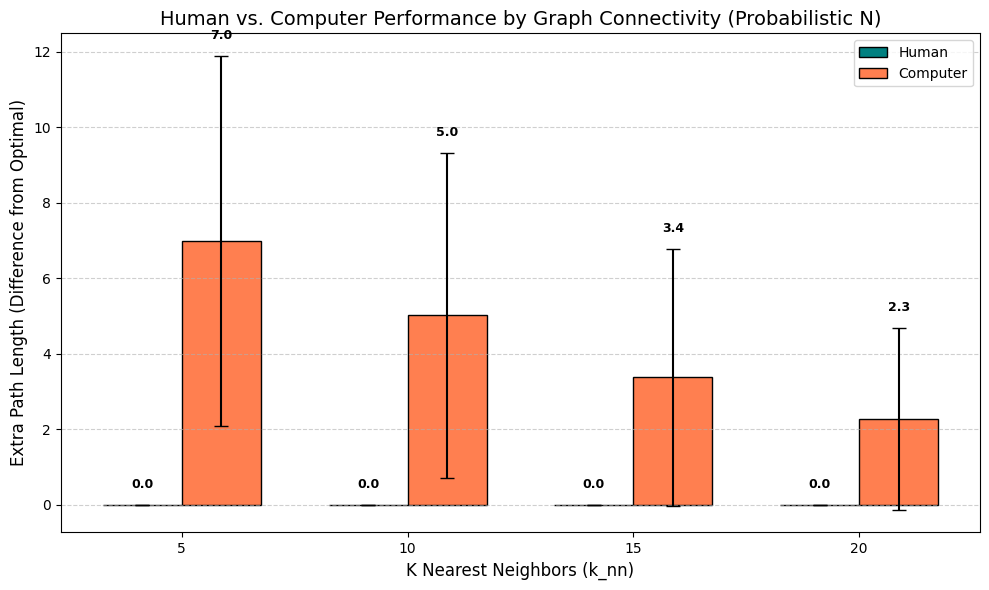

In [14]:
# Calculate the mean difference and standard deviations for successful games
human_success = human_data[human_data['success'] == True]
comp_success = comp_data[comp_data['success'] == True]

h_mean = human_success.groupby('k_nn')['diff'].mean()
h_std = human_success.groupby('k_nn')['diff'].std().fillna(0)

c_mean = comp_success.groupby('k_nn')['diff'].mean()
c_std = comp_success.groupby('k_nn')['diff'].std().fillna(0)

# Merge on k_nn to align the indices just in case some k_values have no data
k_values = sorted(list(set(h_mean.index) | set(c_mean.index)))
x = np.arange(len(k_values))
width = 0.35

# Reindex to ensure alignment
h_mean = h_mean.reindex(k_values).fillna(0)
h_std = h_std.reindex(k_values).fillna(0)
c_mean = c_mean.reindex(k_values).fillna(0)
c_std = c_std.reindex(k_values).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

rects_human = ax.bar(x - width/2, h_mean.values, width, yerr=h_std.values, 
                     capsize=5, label='Human', color='teal', edgecolor='black')

rects_comp = ax.bar(x + width/2, c_mean.values, width, yerr=c_std.values, 
                    capsize=5, label='Computer', color='coral', edgecolor='black')

ax.set_title('Human vs. Computer Performance by Graph Connectivity (Probabilistic N)', fontsize=14)
ax.set_xlabel('K Nearest Neighbors (k_nn)', fontsize=12)
ax.set_ylabel('Extra Path Length (Difference from Optimal)', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(k_values)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend()

ax.bar_label(rects_human, padding=10, fmt='%.1f', fontweight='bold', size=9)
ax.bar_label(rects_comp, padding=10, fmt='%.1f', fontweight='bold', size=9)

plt.tight_layout()
plt.show()

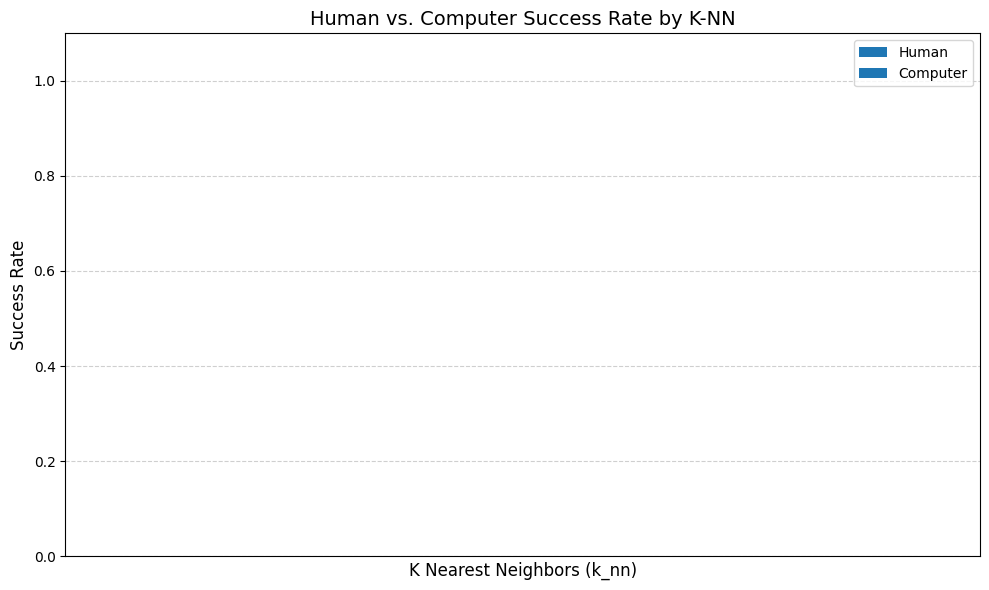

In [5]:
# Plot: Success Rates
h_success_rate = human_data.groupby('k_nn')['success'].mean()
c_success_rate = comp_data.groupby('k_nn')['success'].mean()

h_success_rate = h_success_rate.reindex(k_values).fillna(0)
c_success_rate = c_success_rate.reindex(k_values).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

rects_h_succ = ax.bar(x - width/2, h_success_rate.values, width, 
                     label='Human', color='navy', edgecolor='black')

rects_c_succ = ax.bar(x + width/2, c_success_rate.values, width, 
                    label='Computer', color='darkred', edgecolor='black')

ax.set_title('Human vs. Computer Success Rate by K-NN', fontsize=14)
ax.set_xlabel('K Nearest Neighbors (k_nn)', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(k_values)
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend()

ax.bar_label(rects_h_succ, padding=3, fmt='%.2f', fontweight='bold', size=9)
ax.bar_label(rects_c_succ, padding=3, fmt='%.2f', fontweight='bold', size=9)

plt.tight_layout()
plt.show()